# Level-2: Enhanced model vs Full pre-match

Основной эксперимент работы. Проверяем гипотезу: добавление **предсказаний Level-1** (локальных исходов) к тому же набору pre-match признаков **улучшает** качество предсказания победителя матча

### Пайплайн

Level-1 предсказания сгенерированы для 2024–2026 (expanding window по турнирам). **Train:** все матчи с Level-1 признаками за **2024 и 2025**, кроме тестового хвоста. **Test:** последние 5 турниров 2025 года и весь 2026, попавший в данные.

| Выборка | Описание | Порядок величины (зависит от CSV) |
|---|---|---|
| Train | 2024 + 2025, кроме хвоста | ~1.8–1.9 тыс. матчей |
| Test | хвост 2025 + 2026 | ~0.3 тыс. матчей |

Train аугментируется swap-копией, test нет

### Сравниваем две группы вариантов

**(1) Изолированная предсказательная сила L1** — насколько 5 L1-предсказаний сами по себе предсказывают матч

| Модель | Фичи |
|---|---|
| `L1-only` | только 5 Level-1 предсказаний |
| `Static + L1-only` | round + tournament_level + 5 Level-1 предсказаний |

**(2) Инкрементальный вклад L1 поверх pre-match**:

| Модель | Что добавляем к pre-match |
|---|---|
| `Baseline` (Full pre-match) | ничего |
| `Enh: binary-2` | `prob_set1_winner_team1`, `prob_has_3rd_set` |
| `Enh: regression-2` | `pred_set1_margin_games`, `pred_games_diff_total` |
| `Enh: binary-3` | все 3 бинарных Level-1 таргета |
| `Enh: all-5` | все 5 Level-1 предсказаний |

Сравнение `L1-only` vs `Baseline` отвечает на вопрос являются ли локальные исходы достаточной статистикой: если `L1-only` близок к `Baseline`, то 5 предсказаний сжимают практически весь pre-match сигнал


In [15]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import accuracy_score, log_loss
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import matplotlib.pyplot as plt

REPO_ROOT = Path("../..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from src.symmetry import augment_with_swap

PROCESSED = Path("../../data/processed")
FEATURES = Path("../../data/features")
MODELS = Path("../../models")
MODELS.mkdir(parents=True, exist_ok=True)

N_LAST_2025_TOURNAMENTS = 5

N_SEEDS = 5
BASE_SEED = 42
rng = np.random.default_rng(BASE_SEED)


## Сборка датасета

In [16]:
matches = pd.read_csv(PROCESSED / "matches.csv", parse_dates=["played_at"])
matches["year"] = matches["played_at"].dt.year
matches["target"] = (matches["winner"] == "team_1").astype(int)

blocks_files = {
    "rolling":        FEATURES / "rolling_stats.csv",
    "elo":            FEATURES / "elo.csv",
    "pair_chemistry": FEATURES / "pair_chemistry.csv",
    "h2h":            FEATURES / "head_to_head.csv",
    "form":           FEATURES / "form_and_streaks.csv",
    "rest":           FEATURES / "rest_and_load.csv",
    "context":        FEATURES / "context.csv",
    "matchup":        FEATURES / "matchup.csv",
}

le = LabelEncoder()
matches["tournament_level_enc"] = le.fit_transform(matches["tournament_level"].fillna("unknown"))
static_cols = ["round", "tournament_level_enc"]

data = matches[["match_id", "tournament_id", "played_at", "year", "target"] + static_cols].copy()
prematch_cols = list(static_cols)
for name, p in blocks_files.items():
    b = pd.read_csv(p)
    data = data.merge(b, on="match_id", how="left")
    prematch_cols += [c for c in b.columns if c != "match_id"]

level1 = pd.read_csv(FEATURES / "level1_predictions.csv")
data = data.merge(level1, on="match_id", how="left")
level1_cols = [c for c in level1.columns if c != "match_id"]

# Энкод категориальных
str_cols = data.select_dtypes(include="object").columns.tolist()
for c in str_cols:
    data[c] = LabelEncoder().fit_transform(data[c].astype(str).fillna("nan"))

print(f"Pre-match признаков: {len(prematch_cols)}")
print(f"Level-1 признаков:   {len(level1_cols)}")

Pre-match признаков: 594
Level-1 признаков:   5


## Split

Берём только матчи, для которых есть Level-1 предсказания. **Train:** годы 2024 и 2025, исключая тестовый хвост. **Test:** последние 5 турниров 2025 года и весь 2026 в выборке.

Train аугментируется swap-копией.


In [17]:
L2_TRAIN_FIRST_YEAR = 2024  # фиксированный train: с 2024 по 2025 без хвоста

has_l1 = data[level1_cols[0]].notna()
data_l1 = data[has_l1 & (data["year"] >= L2_TRAIN_FIRST_YEAR)].copy()

tour_starts_2025 = (
    data_l1[data_l1["year"] == 2025]
    .groupby("tournament_id")["played_at"].min()
    .sort_values()
)
last_2025_tids = tour_starts_2025.tail(N_LAST_2025_TOURNAMENTS).index.tolist()

is_test = (data_l1["tournament_id"].isin(last_2025_tids)) | (data_l1["year"] == 2026)
train = data_l1[~is_test].copy()
test = data_l1[is_test].copy()
train_aug = augment_with_swap(
    train,
    binary_invert_cols=("target", "prob_set1_winner_team1"),
    negate_cols=("pred_set1_margin_games", "pred_games_diff_total"),
)

train_year_counts = train.groupby("year").size().to_dict()
print(f"Train (с {L2_TRAIN_FIRST_YEAR} по 2025 до хвоста): {len(train)} матчей, по годам: {train_year_counts}, после swap: {len(train_aug)}")
print(f"Test: {len(test)} матчей")
print(f"Train target mean: {train_aug['target'].mean():.3f}")
print(f"Test target mean: {test['target'].mean():.3f}")


Train (с 2024 по 2025 до хвоста): 1864 матчей, по годам: {2024: 1041, 2025: 823}, после swap: 3728
Test: 332 матчей
Train target mean: 0.500
Test target mean: 0.479


/Users/yan/Desktop/HSE/HSE_Padel/src/symmetry.py:163: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out["is_swapped"] = 1


## Обучение по Level-1 фичам

Собираем 5 моделей: Baseline (без L1) и 4 Enhanced с разными подмножествами Level-1 предсказаний. Все модели обучаются на swap-аугментированном train.

In [18]:
METRICS = ["accuracy", "log_loss"]

XGB_PARAMS = dict(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss",
)


def fit_xgb(train, features, seed, target="target"):
    m = xgb.XGBClassifier(random_state=seed, **XGB_PARAMS)
    m.fit(train[features], train[target], verbose=False)
    return m


def metrics(y_true, y_prob):
    return {
        "accuracy": accuracy_score(y_true, (y_prob >= 0.5).astype(int)),
        "log_loss": log_loss(y_true, y_prob, labels=[0, 1]),
    }


bin_l1 = [c for c in level1_cols if c.startswith("prob_")]
reg_l1 = [c for c in level1_cols if c.startswith("pred_")]
bin_l1_2 = [c for c in ("prob_set1_winner_team1", "prob_has_3rd_set") if c in level1_cols]

variants = {
    "L1-only":                       list(level1_cols),
    "Static + L1-only":              list(static_cols) + list(level1_cols),
    "Baseline (Full pre-match)":     list(prematch_cols),
    "Enh: binary-2":                 list(prematch_cols) + bin_l1_2,
    "Enh: regression-2":             list(prematch_cols) + reg_l1,
    "Enh: binary-3":                 list(prematch_cols) + bin_l1,
    "Enh: all-5":                    list(prematch_cols) + list(level1_cols),
}

seeds = list(range(BASE_SEED, BASE_SEED + N_SEEDS))
y_test = test["target"].values

trained_base = {}
probas_base = {}

raw_rows = []
for name, feats in variants.items():
    for seed in seeds:
        model = fit_xgb(train_aug, feats, seed)
        prob = model.predict_proba(test[feats])[:, 1]

        m = metrics(y_test, prob)
        m.update({"model": name, "seed": seed, "n_features": len(feats)})
        raw_rows.append(m)

        if seed == BASE_SEED:
            trained_base[name] = (model, feats)
            probas_base[name] = prob
    print(f"{name:30s} done ({len(feats):4d} фич)")

raw = pd.DataFrame(raw_rows)

model_base, feats_base = trained_base["Baseline (Full pre-match)"]
model_enh,  feats_enh  = trained_base["Enh: all-5"]
prob_base = probas_base["Baseline (Full pre-match)"]
prob_enh  = probas_base["Enh: all-5"]


L1-only                        done (   5 фич)
Static + L1-only               done (   7 фич)
Baseline (Full pre-match)      done ( 594 фич)
Enh: binary-2                  done ( 596 фич)
Enh: regression-2              done ( 596 фич)
Enh: binary-3                  done ( 597 фич)
Enh: all-5                     done ( 599 фич)


In [19]:
def fmt(med, lo, hi):
    return f"{med:.3f} [{lo:.3f}, {hi:.3f}]"


def summary(df):
    rows = []
    for name in variants:
        sub = df[df["model"] == name]
        row = {"model": name}
        for m in METRICS:
            v = sub[m]
            row[m] = fmt(v.median(), v.quantile(0.25), v.quantile(0.75))
        rows.append(row)
    return pd.DataFrame(rows).set_index("model")


summary(raw)

,accuracy,log_loss
model,,
L1-only,"0.789 [0.783, 0.789]","0.457 [0.453, 0.459]"
Static + L1-only,"0.786 [0.783, 0.792]","0.455 [0.454, 0.461]"
Baseline (Full pre-match),"0.780 [0.771, 0.780]","0.471 [0.467, 0.473]"
Enh: binary-2,"0.780 [0.777, 0.783]","0.467 [0.467, 0.467]"
Enh: regression-2,"0.774 [0.771, 0.780]","0.471 [0.470, 0.473]"
Enh: binary-3,"0.777 [0.768, 0.777]","0.462 [0.461, 0.464]"
Enh: all-5,"0.774 [0.774, 0.774]","0.468 [0.465, 0.469]"


## Feature importance у Enhanced

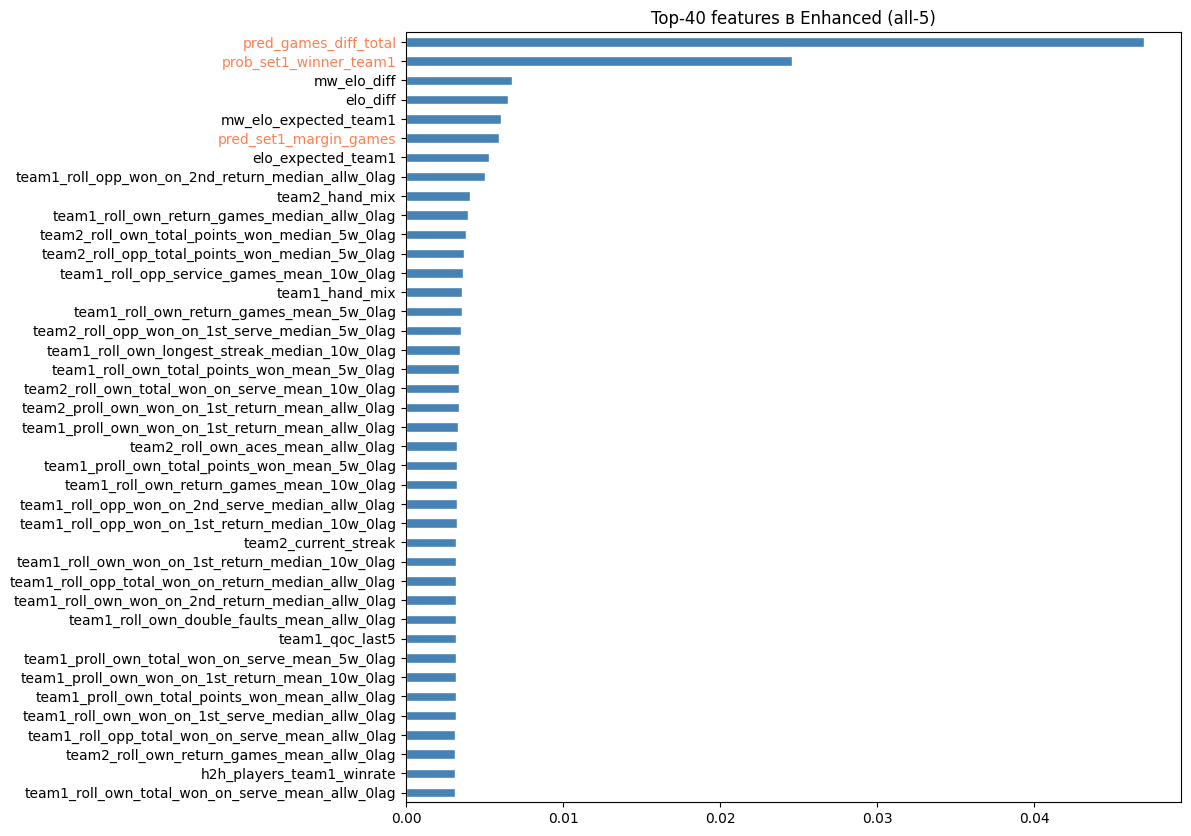

Топ-20 фич (Enhanced all-5):
pred_games_diff_total                                0.0470
prob_set1_winner_team1                               0.0246
mw_elo_diff                                          0.0068
elo_diff                                             0.0065
mw_elo_expected_team1                                0.0060
pred_set1_margin_games                               0.0059
elo_expected_team1                                   0.0053
team1_roll_opp_won_on_2nd_return_median_allw_0lag    0.0050
team2_hand_mix                                       0.0041
team1_roll_own_return_games_median_allw_0lag         0.0040
team2_roll_own_total_points_won_median_5w_0lag       0.0038
team2_roll_opp_total_points_won_median_5w_0lag       0.0037
team1_roll_opp_service_games_mean_10w_0lag           0.0036
team1_hand_mix                                       0.0036
team1_roll_own_return_games_mean_5w_0lag             0.0035
team2_roll_opp_won_on_1st_serve_median_5w_0lag       0.0035
team1_roll_

In [24]:
importance = pd.Series(model_enh.feature_importances_, index=feats_enh).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
importance.head(40).plot.barh(ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top-40 features в Enhanced (all-5)")
ax.invert_yaxis()

for i, (label, _) in enumerate(importance.head(40).items()):
    if label in level1_cols:
        ax.get_yticklabels()[i].set_color("coral")
plt.show()

print("Топ-20 фич (Enhanced all-5):")
print(importance.head(20).round(4).to_string())

print("\nРанги Level-1 фич:")
ranks = pd.Series(range(1, len(importance) + 1), index=importance.index)
for c in level1_cols:
    print(f"  {c}: rank {ranks[c]} / {len(importance)} (importance={importance[c]:.4f})")


## Анализ ошибок: где Enhanced помог или навредил

Смотрим матчи, в которых Enhanced и Baseline дают разные предсказания.

In [21]:
analysis = test[["match_id", "played_at", "target"]].copy()
analysis["prob_base"] = prob_base
analysis["prob_enh"] = prob_enh
analysis["pred_base"] = (prob_base >= 0.5).astype(int)
analysis["pred_enh"] = (prob_enh >= 0.5).astype(int)

flipped = analysis[analysis["pred_base"] != analysis["pred_enh"]].copy()
flipped["enh_correct"] = flipped["pred_enh"] == flipped["target"]

print(f"Матчей, где Enhanced изменил предсказание Baseline: {len(flipped)}")
if len(flipped):
    print(f"  из них Enhanced был прав: {flipped['enh_correct'].sum()} ({flipped['enh_correct'].mean():.1%})")
    print(f"  из них Enhanced ошибся:  {(~flipped['enh_correct']).sum()} ({(~flipped['enh_correct']).mean():.1%})")

Матчей, где Enhanced изменил предсказание Baseline: 13
  из них Enhanced был прав: 8 (61.5%)
  из них Enhanced ошибся:  5 (38.5%)


In [23]:
model_base.save_model(MODELS / f"full_prematch_train{L2_TRAIN_FIRST_YEAR}.json")
model_enh.save_model(MODELS / f"enhanced_level2_train{L2_TRAIN_FIRST_YEAR}.json")

out = test[["match_id", "target"]].copy()
for name in variants:
    tag = name.replace("Baseline (Full pre-match)", "baseline") \
              .replace("Enh: ", "enh_").replace(" ", "_").replace("-", "_").lower()
    out[f"prob_{tag}_seed{BASE_SEED}"] = probas_base[name]
out.to_csv(FEATURES / "level2_predictions.csv", index=False)

raw.to_csv(FEATURES / "level2_raw_results.csv", index=False)